In [1]:
from sklearn import datasets
import numpy as np

In [2]:
iris = datasets.load_iris()

In [3]:
X = iris.get("data")[:, [2, 3]]
y = iris.target

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [6]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

In [7]:
y_pred = ppn.predict(X_test_std)
print("Misclassified examples: %d" % (y_test != y_pred).sum())

Misclassified examples: 1


In [8]:
# Calculating the Classification Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9777777777777777

In [9]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ("o", "s", "^", "v", "<")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[: len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)
    )
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black",
        )
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c="none",
            edgecolor="black",
            alpha=1.0,
            linewidth=1,
            marker="o",
            s=100,
            label="Test set",
        )

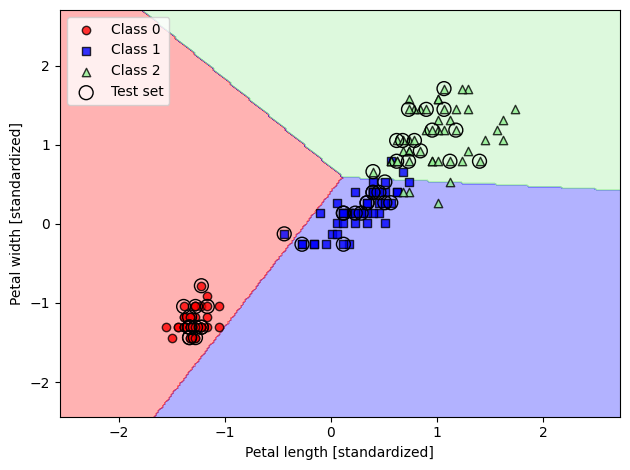

In [10]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(
    X=X_combined_std, y=y_combined, classifier=ppn, test_idx=range(105, 150)
)
plt.xlabel("Petal length [standardized]")
plt.ylabel("Petal width [standardized]")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

In [11]:
class LogisticRegressionGD:  # Batch Gradient Descent
    def __init__(self, lr=0.01, epochs=50, random_state=1) -> None:
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.0)

        self.losses_ = []

        for _ in range(self.epochs):
            net_input = self.net_input(X)
            output = self.activation(net_input)

            errors = y - output
            self.w_ += self.lr * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.lr * 2.0 * errors.mean()

            loss = (-y.dot(np.log(output))) - (
                (1 - y).dot(np.log(1 - output)) / X.shape[0]
            )
            self.losses_.append(loss)

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.5, 1, 0)

    def activation(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

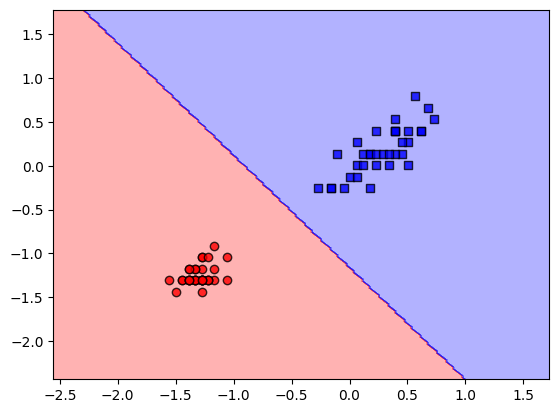

In [12]:
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

lrgd = LogisticRegressionGD(lr=0.3, epochs=1000, random_state=1)
lrgd.fit(X_train_01_subset, y_train_01_subset)

plot_decision_regions(X=X_train_01_subset, y=y_train_01_subset, classifier=lrgd)

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0)

---
### Regularization


##### we fitted 10 logistic regression models with different values for the inverse-regularization parameter, C

/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/slayer0x10/dev/ml/ml-study/.

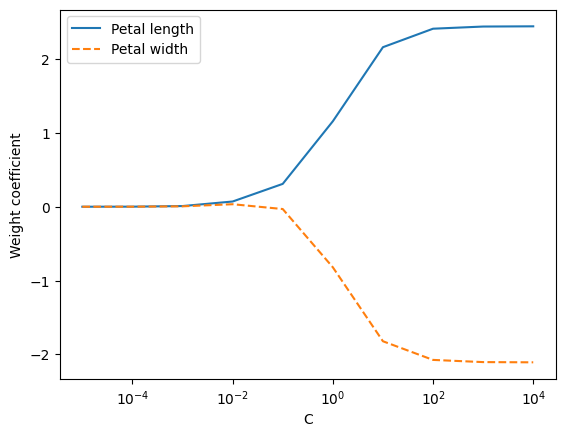

In [ ]:
weights, params = [], []
for c in np.arange(-5, 5):
    lr = LogisticRegression(C=10.0**c, multi_class="ovr")
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10.0**c)

weights = np.array(weights)
plt.plot(params, weights[:, 0], label="Petal length")
plt.plot(params, weights[:, 1], linestyle="--", label="Petal width")
plt.ylabel("Weight coefficient")
plt.xlabel("C")
plt.legend(loc="upper left")
plt.xscale("log")
# plt.savefig('figures/03_08.png', dpi=300)
plt.show()

---
### Solving non-linear problems using a kernel SVM

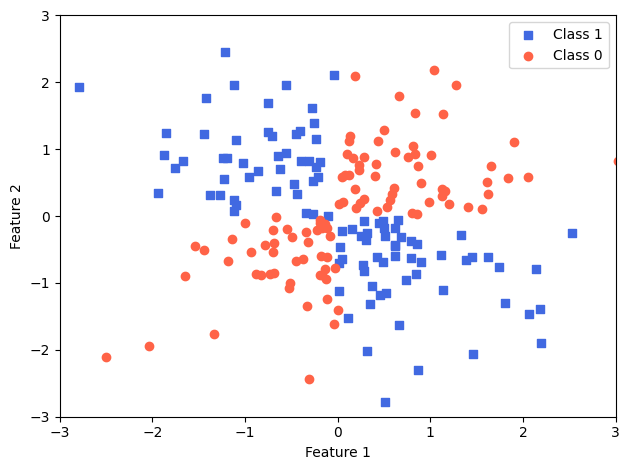

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

plt.scatter(
    X_xor[y_xor == 1, 0],
    X_xor[y_xor == 1, 1],
    c="royalblue",
    marker="s",
    label="Class 1",
)
plt.scatter(
    X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c="tomato", marker="o", label="Class 0"
)

plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend(loc="best")
plt.tight_layout()
# plt.savefig('figures/03_12.png', dpi=300)
plt.show()

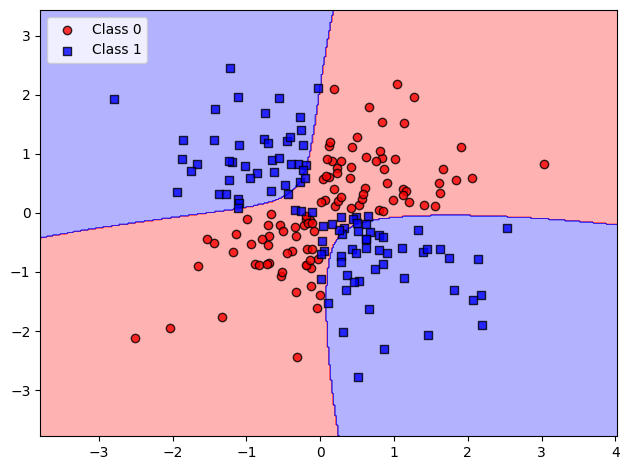

In [22]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", random_state=1, gamma=0.1, C=10.0)
svm.fit(X_xor, y_xor)
plot_decision_regions(X_xor, y_xor, classifier=svm)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


---
### Decision Tree Learning

#### visualize the entropy values for different class distributions 

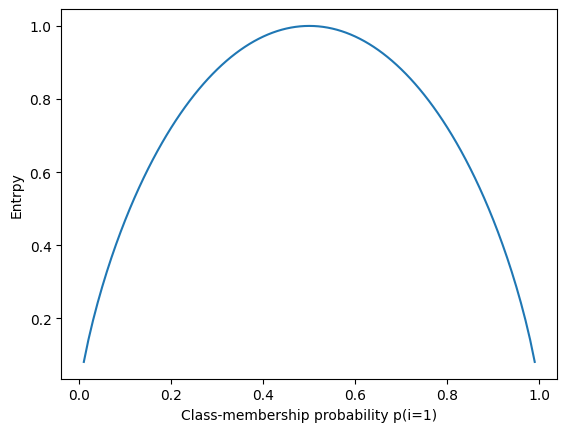

In [24]:
def entropy(p):
    return -p * np.log2(p) - (1 - p) * np.log2((1 - p))


x = np.arange(0.0, 1.0, 0.01)
ent = [entropy(p) if p != 0 else None for p in x]

plt.ylabel("Entrpy")
plt.xlabel("Class-membership probability p(i=1)")
plt.plot(x, ent)

#### Maximizing Information Gain

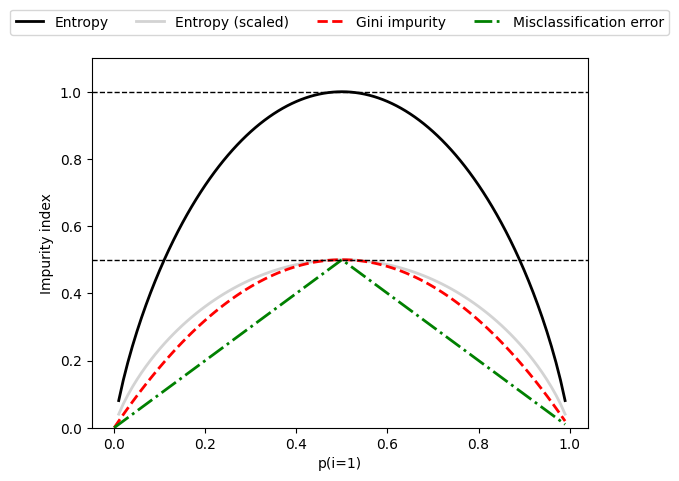

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def gini(p):
    return p * (1 - p) + (1 - p) * (1 - (1 - p))


def entropy(p):
    return -p * np.log2(p) - (1 - p) * np.log2((1 - p))


def error(p):
    return 1 - np.max([p, 1 - p])


x = np.arange(0.0, 1.0, 0.01)

ent = [entropy(p) if p != 0 else None for p in x]
sc_ent = [e * 0.5 if e else None for e in ent]
err = [error(i) for i in x]

fig = plt.figure()
ax = plt.subplot(111)
for (
    i,
    lab,
    ls,
    c,
) in zip(
    [ent, sc_ent, gini(x), err],
    ["Entropy", "Entropy (scaled)", "Gini impurity", "Misclassification error"],
    ["-", "-", "--", "-."],
    ["black", "lightgray", "red", "green", "cyan"],
):
    line = ax.plot(x, i, label=lab, linestyle=ls, lw=2, color=c)

ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=5, fancybox=True, shadow=False
)

ax.axhline(y=0.5, linewidth=1, color="k", linestyle="--")
ax.axhline(y=1.0, linewidth=1, color="k", linestyle="--")
plt.ylim([0, 1.1])
plt.xlabel("p(i=1)")
plt.ylabel("Impurity index")
# plt.savefig('figures/03_19.png', dpi=300, bbox_inches='tight')
plt.show()

---
### Building a decision tree

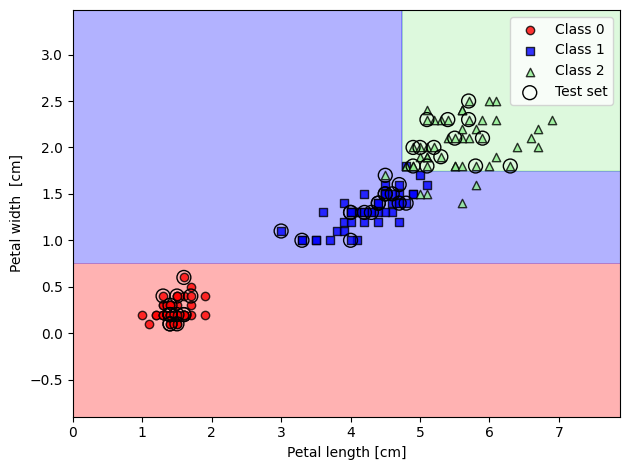

In [37]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=1)
tree.fit(X_train, y_train)

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X_combined, y_combined, classifier=tree, test_idx=range(105, 150))


plt.xlabel("Petal length [cm]")
plt.ylabel("Petal width  [cm]")
plt.tight_layout()
plt.legend()
plt.show()


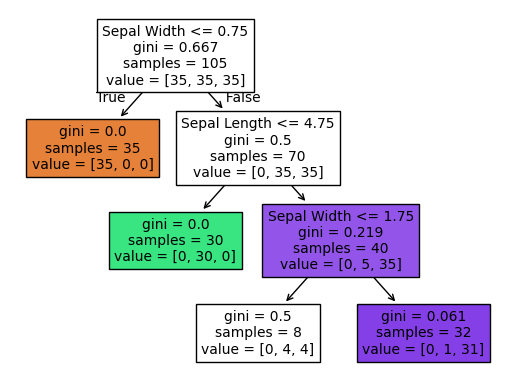

In [38]:
from sklearn import tree as stree

feature_names = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]
stree.plot_tree(tree, feature_names=feature_names, filled=True)
plt.show()

# left branch = True ; right branch = False

#### Random Forests

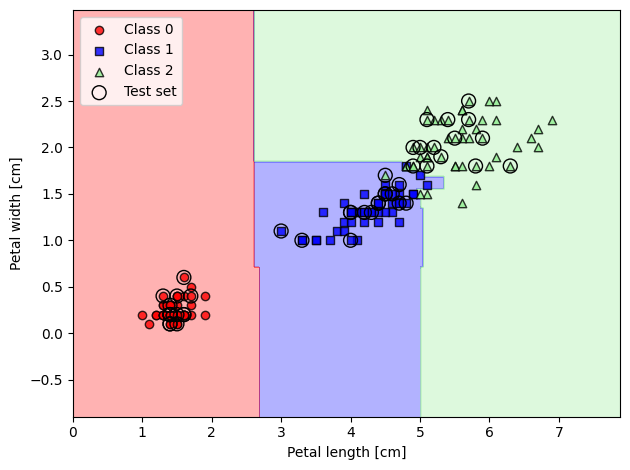

In [43]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=25, random_state=1, n_jobs=-1)
forest.fit(X_train, y_train)

plot_decision_regions(
    X_combined, y_combined, classifier=forest, test_idx=range(105, 150)
)

plt.xlabel("Petal length [cm]")
plt.ylabel("Petal width [cm]")
plt.legend(loc="upper left")
plt.tight_layout()
# plt.savefig('figures/03_2.png', dpi=300)
plt.show()

---
### KNN

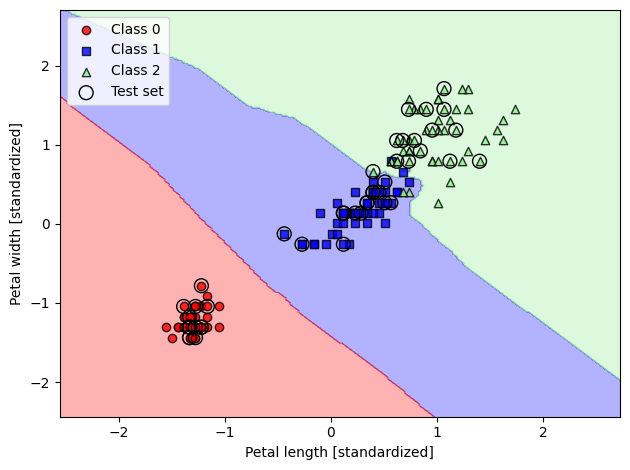

In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, p=2, metric="minkowski")
knn.fit(X_train_std, y_train)

plot_decision_regions(
    X_combined_std, y_combined, classifier=knn, test_idx=range(105, 150)
)

plt.xlabel("Petal length [standardized]")
plt.ylabel("Petal width [standardized]")
plt.legend(loc="upper left")
plt.tight_layout()
# plt.savefig('figures/03_24_figures.png', dpi=300)
plt.show()